# Phase 1 — Missile Intercepteur
## Simulateur Iron Dome — PFA ENSTAB
### Semaine 2 : Pure Pursuit & Proportional Navigation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../src')
from simulation.rocket import RocketRK4, ThreatGenerator

In [2]:
class Interceptor:
    """
    Missile intercepteur avec deux lois de guidage :
    - Pure Pursuit (PP)
    - Proportional Navigation (PN)
    """
    
    def __init__(self, x0, y0, vitesse=800, kill_radius=30):
        """
        Paramètres :
        - x0, y0      : position de lancement du missile
        - vitesse      : vitesse constante du missile (m/s)
        - kill_radius  : rayon de destruction (m)
        """
        self.x0 = x0
        self.y0 = y0
        self.vitesse = vitesse
        self.kill_radius = kill_radius
    
    def _distance(self, x1, y1, x2, y2):
        """Calcule la distance entre deux points."""
        return np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    
    def pure_pursuit(self, cible_x, cible_y, cible_t, dt=0.1):
        """
        Guidage Pure Pursuit :
        À chaque instant, le missile se dirige vers la position
        ACTUELLE de la cible.
        
        Paramètres :
        - cible_x, cible_y : tableaux des positions de la cible
        - cible_t           : tableau des temps de la cible
        - dt                : pas de temps de la simulation
        
        Retourne :
        - résultat dict avec trajectoires, succès, etc.
        """
        # Position initiale du missile
        mx, my = self.x0, self.y0
        
        # Stockage des trajectoires
        missile_x = [mx]
        missile_y = [my]
        missile_t = [0]
        distances = []
        
        t = 0
        intercepte = False
        idx_cible = 0  # index dans le tableau de la cible
        
        while t < cible_t[-1]:
            # Trouver la position actuelle de la cible
            # (chercher l'index correspondant au temps actuel)
            while idx_cible < len(cible_t) - 1 and cible_t[idx_cible] < t:
                idx_cible += 1
            
            cx = cible_x[idx_cible]
            cy = cible_y[idx_cible]
            
            # Calculer la distance missile → cible
            d = self._distance(mx, my, cx, cy)
            distances.append(d)
            
            # Vérifier interception
            if d < self.kill_radius:
                intercepte = True
                break
            
            # === PURE PURSUIT ===
            # Direction vers la cible actuelle
            angle = np.arctan2(cy - my, cx - mx)
            
            # Déplacer le missile dans cette direction
            vx = self.vitesse * np.cos(angle)
            vy = self.vitesse * np.sin(angle)
            
            mx = mx + vx * dt
            my = my + vy * dt
            t += dt
            
            missile_x.append(mx)
            missile_y.append(my)
            missile_t.append(t)
        
        return {
            'missile_x': np.array(missile_x),
            'missile_y': np.array(missile_y),
            'missile_t': np.array(missile_t),
            'intercepte': intercepte,
            'distance_min': min(distances) if distances else float('inf'),
            'temps_interception': t if intercepte else None,
            'methode': 'Pure Pursuit'
        }

In [3]:
# Créer une roquette cible
cible = RocketRK4(v0=300, angle_deg=50, masse=100, Cd=0.3, A=0.05, 
                  x0=-5000, y0=0)
t_c, x_c, y_c = cible.trajectoire_rk4(dt=0.1)

# Créer le missile intercepteur (lancé depuis la zone protégée)
missile = Interceptor(x0=0, y0=0, vitesse=800, kill_radius=30)

# Lancer Pure Pursuit
resultat_pp = missile.pure_pursuit(x_c, y_c, t_c, dt=0.1)

# Afficher le résultat
print(f"Méthode         : {resultat_pp['methode']}")
print(f"Interception    : {'OUI ✅' if resultat_pp['intercepte'] else 'NON ❌'}")
print(f"Distance minimum: {resultat_pp['distance_min']:.2f} m")
if resultat_pp['intercepte']:
    print(f"Temps interception: {resultat_pp['temps_interception']:.2f} s")

Méthode         : Pure Pursuit
Interception    : OUI ✅
Distance minimum: 20.05 m
Temps interception: 5.40 s


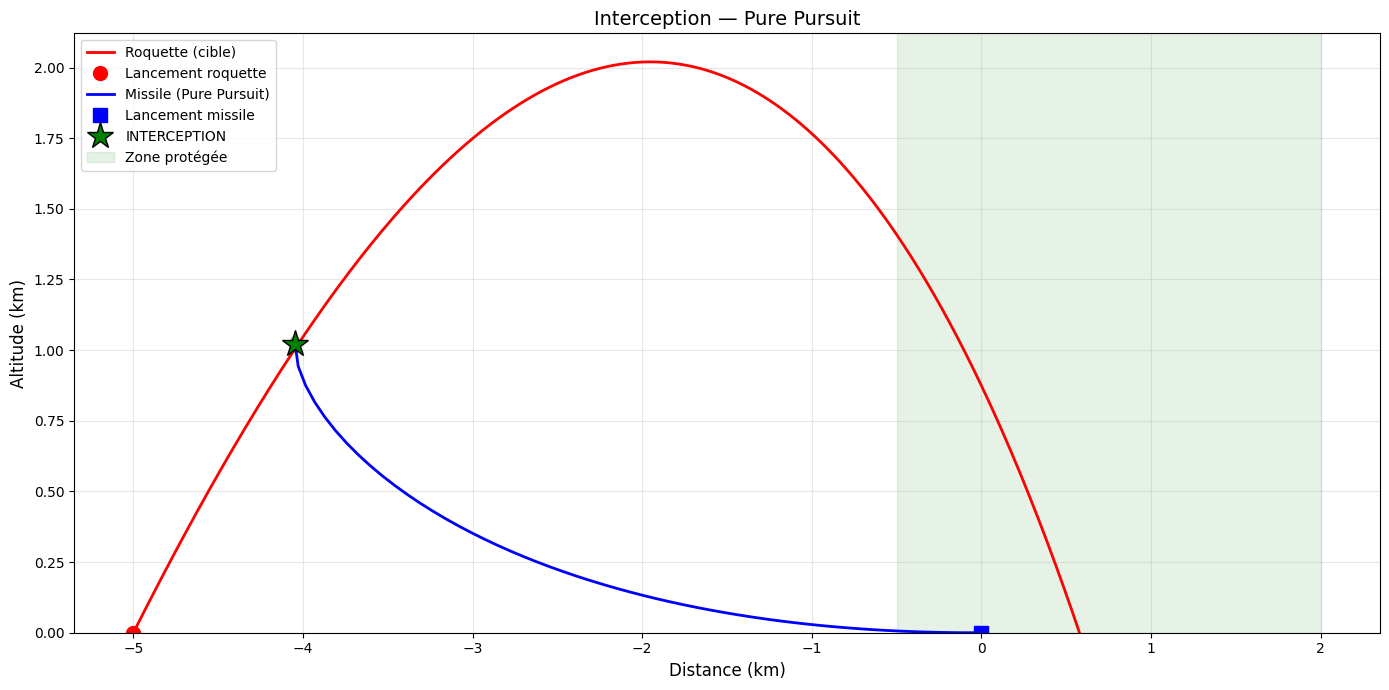

In [4]:
fig, ax = plt.subplots(figsize=(14, 7))

# Trajectoire cible
ax.plot(x_c/1000, y_c/1000, 'r-', linewidth=2, label='Roquette (cible)')
ax.plot(x_c[0]/1000, y_c[0]/1000, 'ro', markersize=10, label='Lancement roquette')

# Trajectoire missile
mx = resultat_pp['missile_x']
my = resultat_pp['missile_y']
ax.plot(mx/1000, my/1000, 'b-', linewidth=2, label='Missile (Pure Pursuit)')
ax.plot(mx[0]/1000, my[0]/1000, 'bs', markersize=10, label='Lancement missile')

# Point d'interception
if resultat_pp['intercepte']:
    ax.plot(mx[-1]/1000, my[-1]/1000, 'g*', markersize=20, 
            markeredgecolor='black', label='INTERCEPTION', zorder=5)
    # Cercle kill radius
    cercle = plt.Circle((mx[-1]/1000, my[-1]/1000), 
                         missile.kill_radius/1000, 
                         color='green', alpha=0.3)
    ax.add_patch(cercle)

# Zone protégée
ax.axvspan(-0.5, 2, alpha=0.1, color='green', label='Zone protégée')

ax.set_xlabel('Distance (km)', fontsize=12)
ax.set_ylabel('Altitude (km)', fontsize=12)
ax.set_title('Interception — Pure Pursuit', fontsize=14)
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig('pure_pursuit.png', dpi=150)
plt.show()

## 2. Proportional Navigation (PN)
Le missile corrige sa trajectoire en fonction du **changement d'angle de visée**.
Plus efficace que Pure Pursuit — trajectoire plus directe.

In [5]:
from scipy import interpolate

def proportional_navigation(self, cible_x, cible_y, cible_t, N=4, dt=0.01):
    mx, my = self.x0, self.y0
    
    t_fine = np.arange(cible_t[0], cible_t[-1], dt)
    if len(t_fine) < 2:
        return {
            'missile_x': np.array([mx]), 'missile_y': np.array([my]),
            'missile_t': np.array([0]), 'intercepte': False,
            'distance_min': float('inf'),
            'temps_interception': None,
            'methode': 'Proportional Navigation'
        }
    
    interp_x = interpolate.interp1d(cible_t, cible_x, fill_value='extrapolate')
    interp_y = interpolate.interp1d(cible_t, cible_y, fill_value='extrapolate')
    cxf = interp_x(t_fine)
    cyf = interp_y(t_fine)
    
    # Contrainte d'altitude minimale pour interception securisee
    min_alt = 200
    best_idx = len(t_fine) // 4
    for i in range(len(t_fine)):
        d = self._distance(mx, my, cxf[i], cyf[i])
        t_missile = d / self.vitesse
        if t_missile <= t_fine[i] and cyf[i] > min_alt:
            best_idx = i
            break
    
    angle_init = np.arctan2(cyf[best_idx] - my, cxf[best_idx] - mx)
    vxm = self.vitesse * np.cos(angle_init)
    vym = self.vitesse * np.sin(angle_init)
    
    missile_x, missile_y, missile_t = [mx], [my], [0]
    distances = []
    t, intercepte, lambda_prev = 0, False, None
    step = 0
    
    while t < t_fine[-1] and step < len(t_fine) - 1:
        cx, cy = cxf[step], cyf[step]
        d = self._distance(mx, my, cx, cy)
        distances.append(d)
        
        if d < self.kill_radius:
            intercepte = True
            break
        if my < -10:
            break
        
        lambda_current = np.arctan2(cy - my, cx - mx)
        if lambda_prev is not None:
            lambda_dot = (lambda_current - lambda_prev) / dt
            while lambda_dot > np.pi / dt:
                lambda_dot -= 2 * np.pi / dt
            while lambda_dot < -np.pi / dt:
                lambda_dot += 2 * np.pi / dt
        else:
            lambda_dot = 0
        lambda_prev = lambda_current
        
        if step < len(t_fine) - 2:
            vxc = (cxf[step+1] - cxf[step]) / dt
            vyc = (cyf[step+1] - cyf[step]) / dt
        else:
            vxc, vyc = 0, 0
        
        dx, dy = cx - mx, cy - my
        v_closing = -((dx * (vxc - vxm) + dy * (vyc - vym)) / d)
        if v_closing < 50:
            v_closing = 50
        
        a_n = N * v_closing * lambda_dot
        a_n = np.clip(a_n, -40 * 9.81, 40 * 9.81)
        
        v_angle = np.arctan2(vym, vxm)
        vxm += -a_n * np.sin(v_angle) * dt
        vym += a_n * np.cos(v_angle) * dt
        
        v_total = np.sqrt(vxm**2 + vym**2)
        vxm = vxm / v_total * self.vitesse
        vym = vym / v_total * self.vitesse
        
        mx += vxm * dt
        my += vym * dt
        t += dt
        step += 1
        missile_x.append(mx)
        missile_y.append(my)
        missile_t.append(t)
    
    return {
        'missile_x': np.array(missile_x),
        'missile_y': np.array(missile_y),
        'missile_t': np.array(missile_t),
        'intercepte': intercepte,
        'distance_min': min(distances) if distances else float('inf'),
        'temps_interception': t if intercepte else None,
        'methode': 'Proportional Navigation'
    }

Interceptor.proportional_navigation = proportional_navigation

In [6]:
resultat_pn = missile.proportional_navigation(x_c, y_c, t_c)


print(f"Méthode         : {resultat_pn['methode']}")
print(f"Interception    : {'OUI ' if resultat_pn['intercepte'] else 'NON '}")
print(f"Distance minimum: {resultat_pn['distance_min']:.2f} m")
if resultat_pn['intercepte']:
    print(f"Temps interception: {resultat_pn['temps_interception']:.2f} s")

Méthode         : Proportional Navigation
Interception    : OUI 
Distance minimum: 22.04 m
Temps interception: 5.20 s


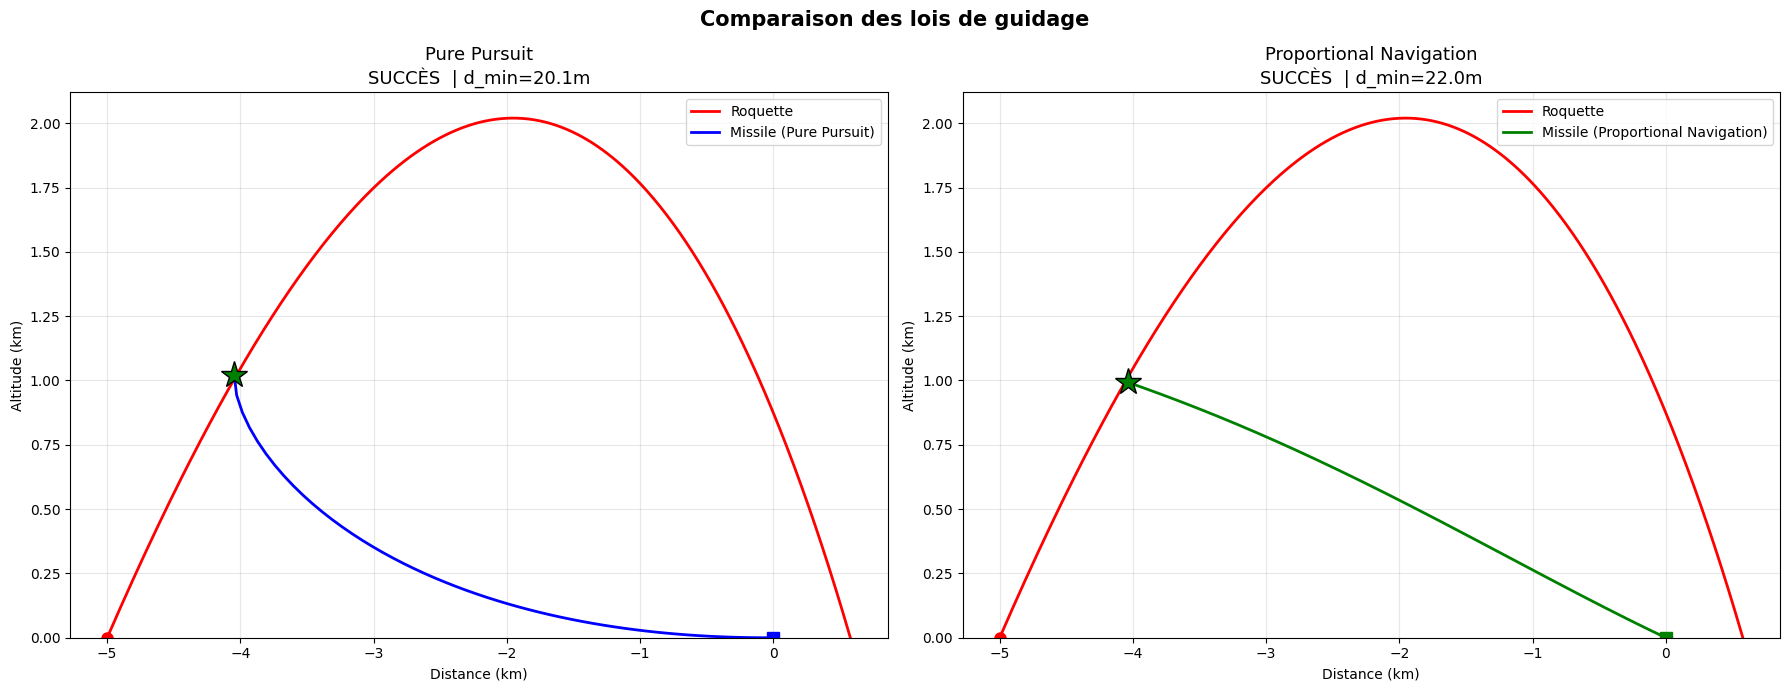

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, resultat, couleur in [(axes[0], resultat_pp, 'blue'), 
                               (axes[1], resultat_pn, 'green')]:
    # Cible
    ax.plot(x_c/1000, y_c/1000, 'r-', linewidth=2, label='Roquette')
    ax.plot(x_c[0]/1000, y_c[0]/1000, 'ro', markersize=8)
    
    # Missile
    mx = resultat['missile_x']
    my = resultat['missile_y']
    ax.plot(mx/1000, my/1000, color=couleur, linewidth=2, 
            label=f"Missile ({resultat['methode']})")
    ax.plot(mx[0]/1000, my[0]/1000, 's', color=couleur, markersize=8)
    
    # Point d'interception
    if resultat['intercepte']:
        ax.plot(mx[-1]/1000, my[-1]/1000, 'g*', markersize=20,
                markeredgecolor='black', zorder=5)
    
    status = "SUCCÈS " if resultat['intercepte'] else "ÉCHEC "
    ax.set_title(f"{resultat['methode']}\n{status} | d_min={resultat['distance_min']:.1f}m", 
                 fontsize=13)
    ax.set_xlabel('Distance (km)')
    ax.set_ylabel('Altitude (km)')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)

plt.suptitle('Comparaison des lois de guidage', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('pp_vs_pn.png', dpi=150)
plt.show()

## 3. Test sur plusieurs scénarios
Tester les deux méthodes sur une salve de roquettes aléatoires.


In [8]:
class EngagementManager:
    def __init__(self, zone_x_min, zone_x_max, interceptor_pos=(0, 0),
                 missile_vitesse=800, kill_radius=30):
        self.zone_x_min = zone_x_min
        self.zone_x_max = zone_x_max
        self.interceptor_pos = interceptor_pos
        self.missile_vitesse = missile_vitesse
        self.kill_radius = kill_radius
    
    def impact_dans_zone(self, cible_x, cible_y):
        x_impact = cible_x[-1]
        return self.zone_x_min <= x_impact <= self.zone_x_max
    
    def _calculer_delai_lancement(self, cible_x, cible_y, cible_t):
        """
        Calcule le moment optimal pour lancer le missile.
        On attend que la roquette soit assez proche pour
        intercepter AU-DESSUS de la zone protégée.
        """
        mx, my = self.interceptor_pos
        zone_centre = (self.zone_x_min + self.zone_x_max) / 2
        
        # Chercher le moment où le missile peut intercepter
        # au-dessus de la zone protégée
        for i in range(len(cible_t)):
            # Distance missile → position cible à cet instant
            d = np.sqrt((cible_x[i] - mx)**2 + (cible_y[i] - my)**2)
            t_vol_missile = d / self.missile_vitesse
            
            # Le missile arrive à temps ET la cible est au-dessus de la zone
            x_cible = cible_x[i]
            dans_zone_x = self.zone_x_min - 2000 <= x_cible <= self.zone_x_max + 1000
            altitude_ok = cible_y[i] > 300
            
            if t_vol_missile <= cible_t[i] and dans_zone_x and altitude_ok:
                # Calculer le délai : lancer pour arriver juste à temps
                delai = max(0, cible_t[i] - t_vol_missile - 1.0)
                return delai
        
        return 0  # lancer immédiatement si pas de solution
    
    def evaluer_menace(self, cible_x, cible_y, cible_t):
        x_impact = cible_x[-1]
        dans_zone = self.impact_dans_zone(cible_x, cible_y)
        return {
            'x_impact': x_impact,
            'dans_zone': dans_zone,
            'decision': 'INTERCEPTER' if dans_zone else 'IGNORER',
        }
    
    def gerer_salve(self, salve):
        resultats = []
        missiles_utilises = 0
        interceptions = 0
        ignorees = 0
        
        for roquette in salve:
            t_c, x_c, y_c = roquette.trajectoire_rk4(dt=0.1)
            evaluation = self.evaluer_menace(x_c, y_c, t_c)
            
            if evaluation['decision'] == 'INTERCEPTER':
                # Calculer le délai de lancement optimal
                delai = self._calculer_delai_lancement(x_c, y_c, t_c)
                
                # Tronquer la trajectoire cible à partir du délai
                idx_debut = np.searchsorted(t_c, delai)
                if idx_debut >= len(t_c) - 10:
                    idx_debut = 0
                
                x_c_tronque = x_c[idx_debut:]
                y_c_tronque = y_c[idx_debut:]
                t_c_tronque = t_c[idx_debut:] - t_c[idx_debut]
                
                missile = Interceptor(
                    x0=self.interceptor_pos[0],
                    y0=self.interceptor_pos[1],
                    vitesse=self.missile_vitesse,
                    kill_radius=self.kill_radius
                )
                r = missile.proportional_navigation(x_c_tronque, y_c_tronque, t_c_tronque)
                
                evaluation['interception'] = r
                evaluation['delai_lancement'] = delai
                missiles_utilises += 1
                if r['intercepte']:
                    interceptions += 1
            else:
                evaluation['interception'] = None
                evaluation['delai_lancement'] = None
                ignorees += 1
            
            resultats.append({
                'roquette': roquette,
                'trajectoire': (t_c, x_c, y_c),
                'evaluation': evaluation
            })
        
        return {
            'details': resultats,
            'total_menaces': len(salve),
            'menaces_dangereuses': missiles_utilises,
            'ignorees': ignorees,
            'interceptions': interceptions,
            'missiles_utilises': missiles_utilises,
            'taux_interception': interceptions / max(missiles_utilises, 1) * 100
        }

In [9]:
gen = ThreatGenerator(seed=42)
salve = gen.generer_salve(n=20)

resultats_pp = []
resultats_pn = []

print(f"{'#':<4} {'v0':>6} {'angle':>6} | {'Pure Pursuit':^24} | {'Prop. Navigation':^24}")
print("-" * 70)

for i, roquette in enumerate(salve):
    t_c, x_c, y_c = roquette.trajectoire_rk4(dt=0.1)
    
    missile = Interceptor(x0=0, y0=0, vitesse=800, kill_radius=30)
    
    r_pp = missile.pure_pursuit(x_c, y_c, t_c, dt=0.1)
    r_pn = missile.proportional_navigation(x_c, y_c, t_c)
    
    resultats_pp.append(r_pp)
    resultats_pn.append(r_pn)
    
    # Altitude d'interception
    pp_alt = r_pp['missile_y'][-1] if r_pp['intercepte'] else 0
    pn_alt = r_pn['missile_y'][-1] if r_pn['intercepte'] else 0
    
    if r_pp['intercepte']:
        pp_status = f"OK alt={pp_alt:.0f}m"
    else:
        pp_status = f"ECHEC d={r_pp['distance_min']:.0f}m"
    
    if r_pn['intercepte']:
        pn_status = f"OK alt={pn_alt:.0f}m"
    else:
        pn_status = f"ECHEC d={r_pn['distance_min']:.0f}m"
    
    print(f"{i+1:<4} {roquette.v0:>6.0f} {np.degrees(roquette.angle):>5.1f} | {pp_status:^24} | {pn_status:^24}")

# Résumé
taux_pp = sum(1 for r in resultats_pp if r['intercepte']) / len(resultats_pp) * 100
taux_pn = sum(1 for r in resultats_pn if r['intercepte']) / len(resultats_pn) * 100

print("-" * 70)
print(f"{'Taux interception':>18}        | {'PP: ' + f'{taux_pp:.0f}%':^24} | {'PN: ' + f'{taux_pn:.0f}%':^24}")
print()

# Analyse comparative
print("=== Analyse comparative ===")
pp_alts = [r['missile_y'][-1] for r in resultats_pp if r['intercepte']]
pn_alts = [r['missile_y'][-1] for r in resultats_pn if r['intercepte']]

if pp_alts:
    print(f"PP - Altitude moyenne d'interception : {np.mean(pp_alts):.0f} m")
if pn_alts:
    print(f"PN - Altitude moyenne d'interception : {np.mean(pn_alts):.0f} m")

pp_times = [r['temps_interception'] for r in resultats_pp if r['intercepte']]
pn_times = [r['temps_interception'] for r in resultats_pn if r['intercepte']]

if pp_times:
    print(f"PP - Temps moyen d'interception      : {np.mean(pp_times):.2f} s")
if pn_times:
    print(f"PN - Temps moyen d'interception      : {np.mean(pn_times):.2f} s")

#        v0  angle |       Pure Pursuit       |     Prop. Navigation    
----------------------------------------------------------------------
1       388  62.9 |       OK alt=2116m       |       OK alt=1963m      
2       165  69.0 |       OK alt=930m        |       OK alt=896m       
3       392  67.5 |       OK alt=2592m       |       OK alt=2462m      
4       226  53.6 |       ECHEC d=32m        |       OK alt=1044m      
5       185  43.1 |       OK alt=511m        |       OK alt=509m       
6       200  53.1 |       OK alt=650m        |       OK alt=605m       
7       193  32.9 |       OK alt=390m        |       OK alt=395m       
8       226  34.4 |       OK alt=414m        |       OK alt=423m       
9       274  31.5 |       OK alt=722m        |       OK alt=745m       
10      228  53.4 |       OK alt=774m        |       OK alt=778m       
11      344  72.3 |       OK alt=1228m       |       OK alt=1104m      
12      172  38.8 |       OK alt=309m        |       OK alt=312m

In [10]:
# Créer le manager et générer les résultats
gen = ThreatGenerator(seed=42)
salve = gen.generer_salve(n=20)

manager = EngagementManager(
    zone_x_min=-500,
    zone_x_max=3000,
    interceptor_pos=(0, 0),
    missile_vitesse=800,
    kill_radius=30
)

resultats = manager.gerer_salve(salve)

# Tableau détaillé
print(f"{'#':<4} {'Impact X':>10} {'Dans zone':>10} {'Decision':>14} {'Resultat':>12}")
print("-" * 55)

for i, r in enumerate(resultats['details']):
    ev = r['evaluation']
    impact = f"{ev['x_impact']:.0f} m"
    zone = "OUI" if ev['dans_zone'] else "NON"
    decision = ev['decision']
    
    if ev['interception'] is not None:
        resultat = "OK" if ev['interception']['intercepte'] else "ECHEC"
    else:
        resultat = "-"
    
    print(f"{i+1:<4} {impact:>10} {zone:>10} {decision:>14} {resultat:>12}")

print("-" * 55)
print(f"Total menaces       : {resultats['total_menaces']}")
print(f"Menaces dangereuses : {resultats['menaces_dangereuses']}")
print(f"Ignorees (hors zone): {resultats['ignorees']}")
print(f"Interceptions       : {resultats['interceptions']}")
print(f"Missiles utilises   : {resultats['missiles_utilises']}")
print(f"Taux d'interception : {resultats['taux_interception']:.0f}%")

#      Impact X  Dans zone       Decision     Resultat
-------------------------------------------------------
1        1480 m        OUI    INTERCEPTER           OK
2       -5678 m        NON        IGNORER            -
3       -2567 m        NON        IGNORER            -
4       -3293 m        NON        IGNORER            -
5       -2161 m        NON        IGNORER            -
6        -686 m        NON        IGNORER            -
7       -2052 m        NON        IGNORER            -
8          13 m        OUI    INTERCEPTER           OK
9       -1768 m        NON        IGNORER            -
10       -626 m        NON        IGNORER            -
11       1292 m        OUI    INTERCEPTER           OK
12      -1174 m        NON        IGNORER            -
13      -3448 m        NON        IGNORER            -
14      -3724 m        NON        IGNORER            -
15      -1133 m        NON        IGNORER            -
16       2982 m        OUI    INTERCEPTER           OK
17       

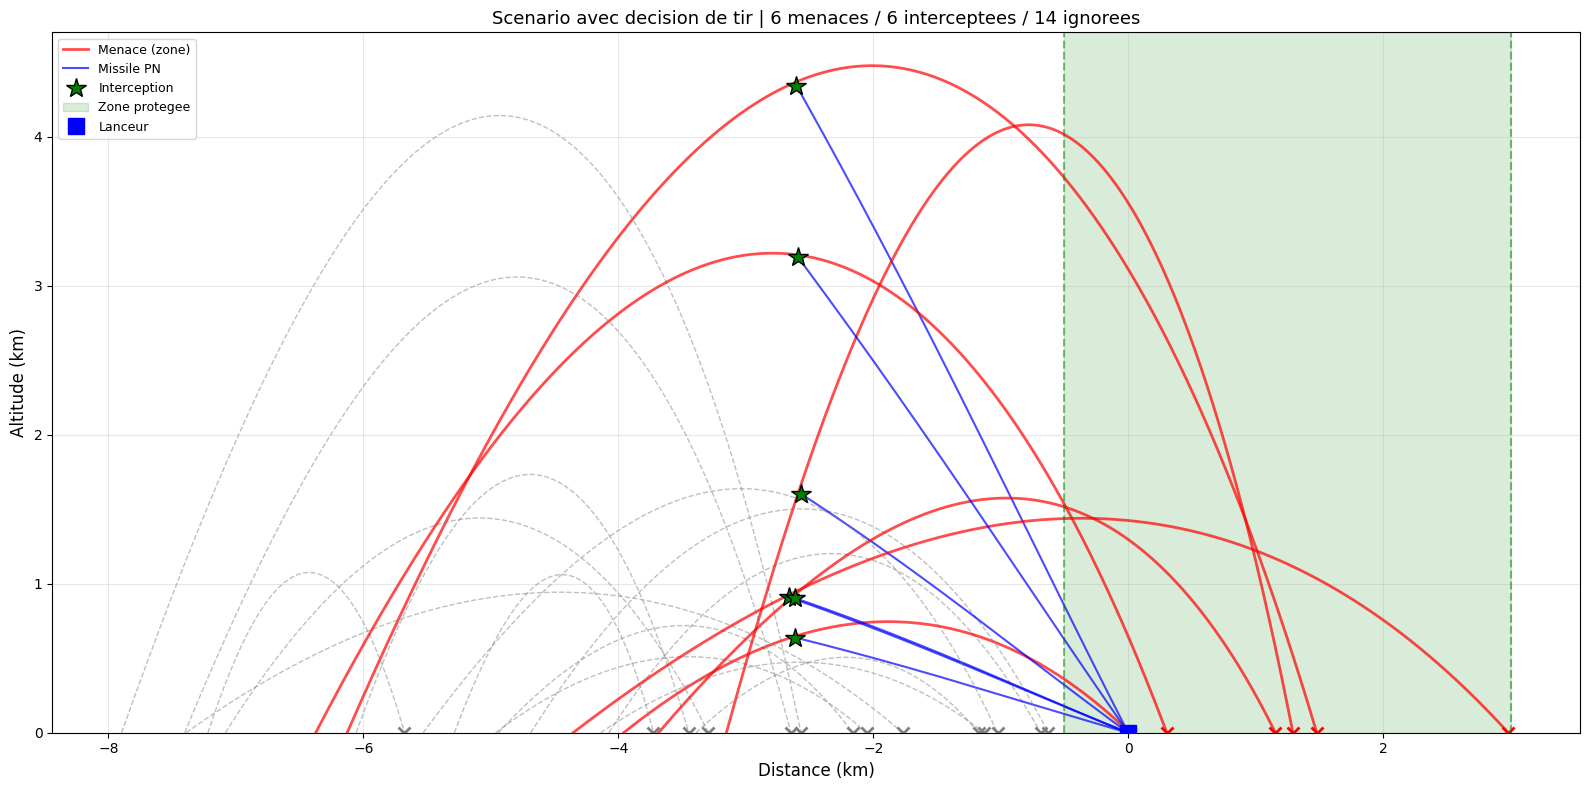

In [11]:
fig, ax = plt.subplots(figsize=(16, 8))

for i, r in enumerate(resultats['details']):
    t_c, x_c, y_c = r['trajectoire']
    ev = r['evaluation']
    
    if ev['dans_zone']:
        # Roquette dangereuse → rouge
        ax.plot(x_c/1000, y_c/1000, 'r-', linewidth=2, alpha=0.7,
                label='Menace (zone)' if i == 0 else '')
        
        # Trajectoire missile
        if ev['interception'] is not None and ev['interception']['intercepte']:
            mx = ev['interception']['missile_x']
            my = ev['interception']['missile_y']
            ax.plot(mx/1000, my/1000, 'b-', linewidth=1.5, alpha=0.7,
                    label='Missile PN' if i == 0 else '')
            ax.plot(mx[-1]/1000, my[-1]/1000, 'g*', markersize=15,
                    markeredgecolor='black', zorder=5,
                    label='Interception' if i == 0 else '')
    else:
        # Roquette ignorée → gris
        ax.plot(x_c/1000, y_c/1000, color='gray', linewidth=1, 
                linestyle='--', alpha=0.5,
                label='Ignoree (hors zone)' if i == 0 else '')
    
    # Point d'impact
    ax.plot(x_c[-1]/1000, 0, 'x', 
            color='red' if ev['dans_zone'] else 'gray',
            markersize=8, markeredgewidth=2)

# Zone protégée
ax.axvspan(-0.5, 3, alpha=0.15, color='green', label='Zone protegee')
ax.axvline(x=-0.5, color='green', linestyle='--', alpha=0.5)
ax.axvline(x=3, color='green', linestyle='--', alpha=0.5)

# Lanceur
ax.plot(0, 0, 'bs', markersize=12, label='Lanceur', zorder=5)

ax.set_xlabel('Distance (km)', fontsize=12)
ax.set_ylabel('Altitude (km)', fontsize=12)
ax.set_title(f'Scenario avec decision de tir | '
             f'{resultats["menaces_dangereuses"]} menaces / '
             f'{resultats["interceptions"]} interceptees / '
             f'{resultats["ignorees"]} ignorees', fontsize=13)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig('scenario_decision.png', dpi=150)
plt.show()

## Extension 3D — Interceptor en trois dimensions
Navigation Proportionnelle adaptée à l'espace 3D avec deux angles :
- **Azimut** (direction horizontale)
- **Élévation** (direction verticale)

In [12]:
import plotly.graph_objects as go
from scipy import interpolate
import sys
sys.path.append('../src')
from simulation.rocket3d import Rocket3D, ThreatGenerator3D

In [13]:
class Interceptor3D:
    """
    Missile intercepteur en 3D.
    Axes : x (distance), y (altitude), z (latéral)
    """
    
    def __init__(self, x0, y0, z0, vitesse=800, kill_radius=30):
        self.x0 = x0
        self.y0 = y0
        self.z0 = z0
        self.vitesse = vitesse
        self.kill_radius = kill_radius
    
    def _distance(self, x1, y1, z1, x2, y2, z2):
        return np.sqrt((x2-x1)**2 + (y2-y1)**2 + (z2-z1)**2)
    
    def pure_pursuit_3d(self, cx, cy, cz, ct, dt=0.1):
        """Pure Pursuit en 3D : le missile pointe toujours vers la cible."""
        mx, my, mz = self.x0, self.y0, self.z0
        mxl, myl, mzl, mtl = [mx], [my], [mz], [0]
        dists = []
        t, ok, ic = 0, False, 0
        
        while t < ct[-1]:
            while ic < len(ct)-1 and ct[ic] < t:
                ic += 1
            
            d = self._distance(mx, my, mz, cx[ic], cy[ic], cz[ic])
            dists.append(d)
            
            if d < self.kill_radius:
                ok = True
                break
            
            # Direction vers la cible
            dx = cx[ic] - mx
            dy = cy[ic] - my
            dz = cz[ic] - mz
            dist_total = np.sqrt(dx**2 + dy**2 + dz**2)
            
            # Déplacer le missile
            mx += self.vitesse * (dx / dist_total) * dt
            my += self.vitesse * (dy / dist_total) * dt
            mz += self.vitesse * (dz / dist_total) * dt
            t += dt
            
            mxl.append(mx); myl.append(my); mzl.append(mz); mtl.append(t)
        
        return {
            'missile_x': np.array(mxl), 'missile_y': np.array(myl),
            'missile_z': np.array(mzl), 'missile_t': np.array(mtl),
            'intercepte': ok,
            'distance_min': min(dists) if dists else float('inf'),
            'temps_interception': t if ok else None,
            'methode': 'Pure Pursuit 3D'
        }
    
    def proportional_navigation_3d(self, cx, cy, cz, ct, N=4, dt=0.01):
        """
        Navigation Proportionnelle en 3D.
        Deux LOS rates : azimut et élévation.
        """
        mx, my, mz = self.x0, self.y0, self.z0
        
        # Interpoler la trajectoire cible
        t_fine = np.arange(ct[0], ct[-1], dt)
        if len(t_fine) < 2:
            return {
                'missile_x': np.array([mx]), 'missile_y': np.array([my]),
                'missile_z': np.array([mz]), 'missile_t': np.array([0]),
                'intercepte': False, 'distance_min': float('inf'),
                'temps_interception': None, 'methode': 'PN 3D'
            }
        
        interp_x = interpolate.interp1d(ct, cx, fill_value='extrapolate')
        interp_y = interpolate.interp1d(ct, cy, fill_value='extrapolate')
        interp_z = interpolate.interp1d(ct, cz, fill_value='extrapolate')
        cxf = interp_x(t_fine)
        cyf = interp_y(t_fine)
        czf = interp_z(t_fine)
        
        # Point d'interception optimal
        bi = len(t_fine) // 4
        for i in range(len(t_fine)):
            d = self._distance(mx, my, mz, cxf[i], cyf[i], czf[i])
            if d / self.vitesse <= t_fine[i] and cyf[i] > 200:
                bi = i
                break
        
        # Direction initiale
        ddx = cxf[bi] - mx
        ddy = cyf[bi] - my
        ddz = czf[bi] - mz
        di = np.sqrt(ddx**2 + ddy**2 + ddz**2)
        vxm = self.vitesse * ddx / di
        vym = self.vitesse * ddy / di
        vzm = self.vitesse * ddz / di
        
        mxl, myl, mzl, mtl = [mx], [my], [mz], [0]
        dists = []
        t, ok, s = 0, False, 0
        prev_az, prev_el = None, None
        
        while t < t_fine[-1] and s < len(t_fine) - 1:
            tcx, tcy, tcz = cxf[s], cyf[s], czf[s]
            d = self._distance(mx, my, mz, tcx, tcy, tcz)
            dists.append(d)
            
            if d < self.kill_radius:
                ok = True
                break
            if my < -10:
                break
            
            # Angles LOS (azimut et élévation)
            ddx, ddy, ddz = tcx - mx, tcy - my, tcz - mz
            az = np.arctan2(ddz, ddx)
            el = np.arctan2(ddy, np.sqrt(ddx**2 + ddz**2))
            
            # Taux de rotation
            if prev_az is not None:
                az_dot = (az - prev_az) / dt
                el_dot = (el - prev_el) / dt
                while az_dot > np.pi/dt: az_dot -= 2*np.pi/dt
                while az_dot < -np.pi/dt: az_dot += 2*np.pi/dt
                while el_dot > np.pi/dt: el_dot -= 2*np.pi/dt
                while el_dot < -np.pi/dt: el_dot += 2*np.pi/dt
            else:
                az_dot, el_dot = 0, 0
            prev_az, prev_el = az, el
            
            # Vitesse cible estimée
            if s < len(t_fine) - 2:
                vxc = (cxf[s+1] - cxf[s]) / dt
                vyc = (cyf[s+1] - cyf[s]) / dt
                vzc = (czf[s+1] - czf[s]) / dt
            else:
                vxc, vyc, vzc = 0, 0, 0
            
            # Vitesse de fermeture
            vc = -((ddx*(vxc-vxm) + ddy*(vyc-vym) + ddz*(vzc-vzm)) / d)
            if vc < 50: vc = 50
            
            # Corrections PN
            a_az = np.clip(N * vc * az_dot, -40*9.81, 40*9.81)
            a_el = np.clip(N * vc * el_dot, -40*9.81, 40*9.81)
            
            # Appliquer les corrections
            v_az = np.arctan2(vzm, vxm)
            v_el = np.arctan2(vym, np.sqrt(vxm**2 + vzm**2))
            
            vxm += -a_az * np.sin(v_az) * dt
            vzm += a_az * np.cos(v_az) * dt
            vym += a_el * np.cos(v_el) * dt
            
            # Normaliser
            vt = np.sqrt(vxm**2 + vym**2 + vzm**2)
            vxm = vxm/vt * self.vitesse
            vym = vym/vt * self.vitesse
            vzm = vzm/vt * self.vitesse
            
            mx += vxm*dt; my += vym*dt; mz += vzm*dt
            t += dt; s += 1
            mxl.append(mx); myl.append(my); mzl.append(mz); mtl.append(t)
        
        return {
            'missile_x': np.array(mxl), 'missile_y': np.array(myl),
            'missile_z': np.array(mzl), 'missile_t': np.array(mtl),
            'intercepte': ok,
            'distance_min': min(dists) if dists else float('inf'),
            'temps_interception': t if ok else None,
            'methode': 'PN 3D'
        }

In [14]:
gen3d = ThreatGenerator3D(seed=42)
salve3d = gen3d.generer_salve(n=10)

print(f"{'#':<4} {'v0':>5} {'theta':>6} {'phi':>5} | {'PP 3D':^20} | {'PN 3D':^20}")
print("-" * 65)

resultats_pp3d = []
resultats_pn3d = []

for i, r in enumerate(salve3d):
    tc, xc, yc, zc = r.trajectoire_rk4(dt=0.1)
    m = Interceptor3D(0, 0, 0, vitesse=800, kill_radius=30)
    
    rpp = m.pure_pursuit_3d(xc, yc, zc, tc, dt=0.1)
    rpn = m.proportional_navigation_3d(xc, yc, zc, tc)
    
    resultats_pp3d.append(rpp)
    resultats_pn3d.append(rpn)
    
    ps = f"{'OK' if rpp['intercepte'] else 'ECHEC'} d={rpp['distance_min']:.0f}m"
    ns = f"{'OK' if rpn['intercepte'] else 'ECHEC'} d={rpn['distance_min']:.0f}m"
    print(f"{i+1:<4} {r.v0:>5.0f} {np.degrees(r.theta):>5.1f} {np.degrees(r.phi):>5.1f} | {ps:^20} | {ns:^20}")

taux_pp = sum(1 for r in resultats_pp3d if r['intercepte']) / len(resultats_pp3d) * 100
taux_pn = sum(1 for r in resultats_pn3d if r['intercepte']) / len(resultats_pn3d) * 100

print("-" * 65)
print(f"PP 3D: {taux_pp:.0f}%  |  PN 3D: {taux_pn:.0f}%")

#       v0  theta   phi |        PP 3D         |        PN 3D        
-----------------------------------------------------------------
1      244  72.8   9.3 |       OK d=29m       |       OK d=27m      
2      367  57.1   8.3 |       OK d=23m       |       OK d=21m      
3      195  38.3  -7.8 |       OK d=11m       |       OK d=26m      
4      185  43.1  -5.3 |       OK d=28m       |       OK d=22m      
5      298  32.1   4.3 |       OK d=22m       |       OK d=30m      
6      352  43.7 -16.1 |       OK d=20m       |       OK d=22m      
7      159  70.9  -9.6 |       OK d=22m       |       OK d=26m      
8      196  73.6  11.0 |       OK d=29m       |       OK d=26m      
9      172  38.8 -18.2 |       OK d=30m       |       OK d=27m      
10     239  42.6   1.7 |       OK d=22m       |       OK d=22m      
-----------------------------------------------------------------
PP 3D: 100%  |  PN 3D: 100%


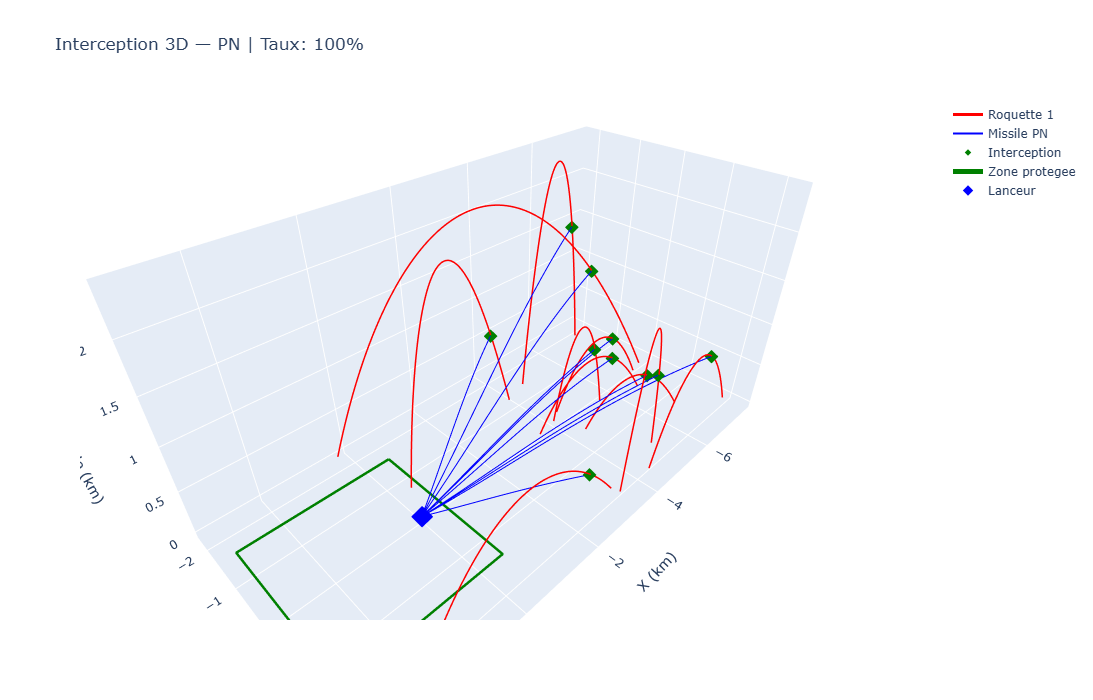

In [15]:
fig = go.Figure()

for i, r in enumerate(salve3d):
    tc, xc, yc, zc = r.trajectoire_rk4(dt=0.1)
    rpn = resultats_pn3d[i]
    
    # Roquette
    fig.add_trace(go.Scatter3d(
        x=xc/1000, y=zc/1000, z=yc/1000,
        mode='lines', line=dict(color='red', width=3),
        name=f'Roquette {i+1}' if i < 3 else None,
        showlegend=(i < 1)
    ))
    
    # Missile
    mx, my, mz = rpn['missile_x'], rpn['missile_y'], rpn['missile_z']
    fig.add_trace(go.Scatter3d(
        x=mx/1000, y=mz/1000, z=my/1000,
        mode='lines', line=dict(color='blue', width=2),
        name=f'Missile PN' if i < 1 else None,
        showlegend=(i < 1)
    ))
    
    # Point d'interception
    if rpn['intercepte']:
        fig.add_trace(go.Scatter3d(
            x=[mx[-1]/1000], y=[mz[-1]/1000], z=[my[-1]/1000],
            mode='markers',
            marker=dict(size=5, color='green', symbol='diamond'),
            name='Interception' if i < 1 else None,
            showlegend=(i < 1)
        ))

# Zone protégée
zone_x = np.array([-0.5, 3, 3, -0.5, -0.5])
zone_z = np.array([-1.5, -1.5, 1.5, 1.5, -1.5])
fig.add_trace(go.Scatter3d(
    x=zone_x, y=zone_z, z=np.zeros(5),
    mode='lines', line=dict(color='green', width=5),
    name='Zone protegee'
))

# Lanceur
fig.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0],
    mode='markers', marker=dict(size=8, color='blue', symbol='diamond'),
    name='Lanceur'
))

fig.update_layout(
    title=f'Interception 3D — PN | Taux: {taux_pn:.0f}%',
    scene=dict(
        xaxis_title='X (km)', yaxis_title='Z (km)', zaxis_title='Altitude (km)',
        aspectmode='manual', aspectratio=dict(x=2, y=1, z=1)
    ),
    width=900, height=700
)
fig.show()

In [16]:
%%writefile ../src/simulation/interceptor.py
import numpy as np
from scipy import interpolate

class Interceptor:
    def __init__(self, x0, y0, vitesse=800, kill_radius=30):
        self.x0 = x0
        self.y0 = y0
        self.vitesse = vitesse
        self.kill_radius = kill_radius
    
    def _distance(self, x1, y1, x2, y2):
        return np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    
    def pure_pursuit(self, cible_x, cible_y, cible_t, dt=0.1):
        mx, my = self.x0, self.y0
        missile_x, missile_y, missile_t = [mx], [my], [0]
        distances = []
        t, intercepte, idx_cible = 0, False, 0
        while t < cible_t[-1]:
            while idx_cible < len(cible_t) - 1 and cible_t[idx_cible] < t:
                idx_cible += 1
            cx, cy = cible_x[idx_cible], cible_y[idx_cible]
            d = self._distance(mx, my, cx, cy)
            distances.append(d)
            if d < self.kill_radius:
                intercepte = True
                break
            angle = np.arctan2(cy - my, cx - mx)
            mx += self.vitesse * np.cos(angle) * dt
            my += self.vitesse * np.sin(angle) * dt
            t += dt
            missile_x.append(mx)
            missile_y.append(my)
            missile_t.append(t)
        return {
            'missile_x': np.array(missile_x), 'missile_y': np.array(missile_y),
            'missile_t': np.array(missile_t), 'intercepte': intercepte,
            'distance_min': min(distances) if distances else float('inf'),
            'temps_interception': t if intercepte else None, 'methode': 'Pure Pursuit'
        }
    
    def proportional_navigation(self, cible_x, cible_y, cible_t, N=4, dt=0.01):
        mx, my = self.x0, self.y0
        t_fine = np.arange(cible_t[0], cible_t[-1], dt)
        if len(t_fine) < 2:
            return {
                'missile_x': np.array([mx]), 'missile_y': np.array([my]),
                'missile_t': np.array([0]), 'intercepte': False,
                'distance_min': float('inf'),
                'temps_interception': None, 'methode': 'Proportional Navigation'
            }
        interp_x = interpolate.interp1d(cible_t, cible_x, fill_value='extrapolate')
        interp_y = interpolate.interp1d(cible_t, cible_y, fill_value='extrapolate')
        cxf = interp_x(t_fine)
        cyf = interp_y(t_fine)
        min_alt = 200
        best_idx = len(t_fine) // 4
        for i in range(len(t_fine)):
            d = self._distance(mx, my, cxf[i], cyf[i])
            t_missile = d / self.vitesse
            if t_missile <= t_fine[i] and cyf[i] > min_alt:
                best_idx = i
                break
        angle_init = np.arctan2(cyf[best_idx] - my, cxf[best_idx] - mx)
        vxm = self.vitesse * np.cos(angle_init)
        vym = self.vitesse * np.sin(angle_init)
        missile_x, missile_y, missile_t = [mx], [my], [0]
        distances = []
        t, intercepte, lambda_prev = 0, False, None
        step = 0
        while t < t_fine[-1] and step < len(t_fine) - 1:
            cx, cy = cxf[step], cyf[step]
            d = self._distance(mx, my, cx, cy)
            distances.append(d)
            if d < self.kill_radius:
                intercepte = True
                break
            if my < -10:
                break
            lambda_current = np.arctan2(cy - my, cx - mx)
            if lambda_prev is not None:
                lambda_dot = (lambda_current - lambda_prev) / dt
                while lambda_dot > np.pi / dt:
                    lambda_dot -= 2 * np.pi / dt
                while lambda_dot < -np.pi / dt:
                    lambda_dot += 2 * np.pi / dt
            else:
                lambda_dot = 0
            lambda_prev = lambda_current
            if step < len(t_fine) - 2:
                vxc = (cxf[step+1] - cxf[step]) / dt
                vyc = (cyf[step+1] - cyf[step]) / dt
            else:
                vxc, vyc = 0, 0
            dx, dy = cx - mx, cy - my
            v_closing = -((dx * (vxc - vxm) + dy * (vyc - vym)) / d)
            if v_closing < 50:
                v_closing = 50
            a_n = N * v_closing * lambda_dot
            a_n = np.clip(a_n, -40 * 9.81, 40 * 9.81)
            v_angle = np.arctan2(vym, vxm)
            vxm += -a_n * np.sin(v_angle) * dt
            vym += a_n * np.cos(v_angle) * dt
            v_total = np.sqrt(vxm**2 + vym**2)
            vxm = vxm / v_total * self.vitesse
            vym = vym / v_total * self.vitesse
            mx += vxm * dt
            my += vym * dt
            t += dt
            step += 1
            missile_x.append(mx)
            missile_y.append(my)
            missile_t.append(t)
        return {
            'missile_x': np.array(missile_x), 'missile_y': np.array(missile_y),
            'missile_t': np.array(missile_t), 'intercepte': intercepte,
            'distance_min': min(distances) if distances else float('inf'),
            'temps_interception': t if intercepte else None,
            'methode': 'Proportional Navigation'
        }


class EngagementManager:
    def __init__(self, zone_x_min, zone_x_max, interceptor_pos=(0, 0),
                 missile_vitesse=800, kill_radius=30):
        self.zone_x_min = zone_x_min
        self.zone_x_max = zone_x_max
        self.interceptor_pos = interceptor_pos
        self.missile_vitesse = missile_vitesse
        self.kill_radius = kill_radius
    
    def impact_dans_zone(self, cible_x, cible_y):
        x_impact = cible_x[-1]
        return self.zone_x_min <= x_impact <= self.zone_x_max
    
    def _calculer_delai_lancement(self, cible_x, cible_y, cible_t):
        mx, my = self.interceptor_pos
        for i in range(len(cible_t)):
            d = np.sqrt((cible_x[i] - mx)**2 + (cible_y[i] - my)**2)
            t_vol_missile = d / self.missile_vitesse
            x_cible = cible_x[i]
            dans_zone_x = self.zone_x_min - 2000 <= x_cible <= self.zone_x_max + 1000
            altitude_ok = cible_y[i] > 300
            if t_vol_missile <= cible_t[i] and dans_zone_x and altitude_ok:
                delai = max(0, cible_t[i] - t_vol_missile - 1.0)
                return delai
        return 0
    
    def evaluer_menace(self, cible_x, cible_y, cible_t):
        x_impact = cible_x[-1]
        dans_zone = self.impact_dans_zone(cible_x, cible_y)
        return {
            'x_impact': x_impact, 'dans_zone': dans_zone,
            'decision': 'INTERCEPTER' if dans_zone else 'IGNORER',
        }
    
    def gerer_salve(self, salve):
        resultats = []
        missiles_utilises = 0
        interceptions = 0
        ignorees = 0
        for roquette in salve:
            t_c, x_c, y_c = roquette.trajectoire_rk4(dt=0.1)
            evaluation = self.evaluer_menace(x_c, y_c, t_c)
            if evaluation['decision'] == 'INTERCEPTER':
                delai = self._calculer_delai_lancement(x_c, y_c, t_c)
                idx_debut = np.searchsorted(t_c, delai)
                if idx_debut >= len(t_c) - 10:
                    idx_debut = 0
                x_c_tronque = x_c[idx_debut:]
                y_c_tronque = y_c[idx_debut:]
                t_c_tronque = t_c[idx_debut:] - t_c[idx_debut]
                missile = Interceptor(
                    x0=self.interceptor_pos[0], y0=self.interceptor_pos[1],
                    vitesse=self.missile_vitesse, kill_radius=self.kill_radius
                )
                r = missile.proportional_navigation(x_c_tronque, y_c_tronque, t_c_tronque)
                evaluation['interception'] = r
                evaluation['delai_lancement'] = delai
                missiles_utilises += 1
                if r['intercepte']:
                    interceptions += 1
            else:
                evaluation['interception'] = None
                evaluation['delai_lancement'] = None
                ignorees += 1
            resultats.append({
                'roquette': roquette,
                'trajectoire': (t_c, x_c, y_c),
                'evaluation': evaluation
            })
        return {
            'details': resultats, 'total_menaces': len(salve),
            'menaces_dangereuses': missiles_utilises, 'ignorees': ignorees,
            'interceptions': interceptions, 'missiles_utilises': missiles_utilises,
            'taux_interception': interceptions / max(missiles_utilises, 1) * 100
        }

Overwriting ../src/simulation/interceptor.py


In [1]:
%%writefile ../src/simulation/interceptor3d.py
import numpy as np
from scipy import interpolate

class Interceptor3D:
    def __init__(self, x0, y0, z0, vitesse=800, kill_radius=30):
        self.x0 = x0
        self.y0 = y0
        self.z0 = z0
        self.vitesse = vitesse
        self.kill_radius = kill_radius
    
    def _distance(self, x1, y1, z1, x2, y2, z2):
        return np.sqrt((x2-x1)**2 + (y2-y1)**2 + (z2-z1)**2)
    
    def pure_pursuit_3d(self, cx, cy, cz, ct, dt=0.1):
        mx, my, mz = self.x0, self.y0, self.z0
        mxl, myl, mzl, mtl = [mx], [my], [mz], [0]
        dists = []
        t, ok, ic = 0, False, 0
        while t < ct[-1]:
            while ic < len(ct)-1 and ct[ic] < t:
                ic += 1
            d = self._distance(mx, my, mz, cx[ic], cy[ic], cz[ic])
            dists.append(d)
            if d < self.kill_radius:
                ok = True
                break
            dx = cx[ic] - mx
            dy = cy[ic] - my
            dz = cz[ic] - mz
            dist_total = np.sqrt(dx**2 + dy**2 + dz**2)
            mx += self.vitesse * (dx / dist_total) * dt
            my += self.vitesse * (dy / dist_total) * dt
            mz += self.vitesse * (dz / dist_total) * dt
            t += dt
            mxl.append(mx); myl.append(my); mzl.append(mz); mtl.append(t)
        return {
            'missile_x': np.array(mxl), 'missile_y': np.array(myl),
            'missile_z': np.array(mzl), 'missile_t': np.array(mtl),
            'intercepte': ok,
            'distance_min': min(dists) if dists else float('inf'),
            'temps_interception': t if ok else None,
            'methode': 'Pure Pursuit 3D'
        }
    
    def proportional_navigation_3d(self, cx, cy, cz, ct, N=4, dt=0.01):
        mx, my, mz = self.x0, self.y0, self.z0
        t_fine = np.arange(ct[0], ct[-1], dt)
        if len(t_fine) < 2:
            return {
                'missile_x': np.array([mx]), 'missile_y': np.array([my]),
                'missile_z': np.array([mz]), 'missile_t': np.array([0]),
                'intercepte': False, 'distance_min': float('inf'),
                'temps_interception': None, 'methode': 'PN 3D'
            }
        interp_x = interpolate.interp1d(ct, cx, fill_value='extrapolate')
        interp_y = interpolate.interp1d(ct, cy, fill_value='extrapolate')
        interp_z = interpolate.interp1d(ct, cz, fill_value='extrapolate')
        cxf = interp_x(t_fine)
        cyf = interp_y(t_fine)
        czf = interp_z(t_fine)
        bi = len(t_fine) // 4
        for i in range(len(t_fine)):
            d = self._distance(mx, my, mz, cxf[i], cyf[i], czf[i])
            if d / self.vitesse <= t_fine[i] and cyf[i] > 200:
                bi = i
                break
        ddx = cxf[bi] - mx
        ddy = cyf[bi] - my
        ddz = czf[bi] - mz
        di = np.sqrt(ddx**2 + ddy**2 + ddz**2)
        vxm = self.vitesse * ddx / di
        vym = self.vitesse * ddy / di
        vzm = self.vitesse * ddz / di
        mxl, myl, mzl, mtl = [mx], [my], [mz], [0]
        dists = []
        t, ok, s = 0, False, 0
        prev_az, prev_el = None, None
        while t < t_fine[-1] and s < len(t_fine) - 1:
            tcx, tcy, tcz = cxf[s], cyf[s], czf[s]
            d = self._distance(mx, my, mz, tcx, tcy, tcz)
            dists.append(d)
            if d < self.kill_radius:
                ok = True
                break
            if my < -10:
                break
            ddx, ddy, ddz = tcx - mx, tcy - my, tcz - mz
            az = np.arctan2(ddz, ddx)
            el = np.arctan2(ddy, np.sqrt(ddx**2 + ddz**2))
            if prev_az is not None:
                az_dot = (az - prev_az) / dt
                el_dot = (el - prev_el) / dt
                while az_dot > np.pi/dt: az_dot -= 2*np.pi/dt
                while az_dot < -np.pi/dt: az_dot += 2*np.pi/dt
                while el_dot > np.pi/dt: el_dot -= 2*np.pi/dt
                while el_dot < -np.pi/dt: el_dot += 2*np.pi/dt
            else:
                az_dot, el_dot = 0, 0
            prev_az, prev_el = az, el
            if s < len(t_fine) - 2:
                vxc = (cxf[s+1] - cxf[s]) / dt
                vyc = (cyf[s+1] - cyf[s]) / dt
                vzc = (czf[s+1] - czf[s]) / dt
            else:
                vxc, vyc, vzc = 0, 0, 0
            vc = -((ddx*(vxc-vxm) + ddy*(vyc-vym) + ddz*(vzc-vzm)) / d)
            if vc < 50: vc = 50
            a_az = np.clip(N * vc * az_dot, -40*9.81, 40*9.81)
            a_el = np.clip(N * vc * el_dot, -40*9.81, 40*9.81)
            v_az = np.arctan2(vzm, vxm)
            v_el = np.arctan2(vym, np.sqrt(vxm**2 + vzm**2))
            vxm += -a_az * np.sin(v_az) * dt
            vzm += a_az * np.cos(v_az) * dt
            vym += a_el * np.cos(v_el) * dt
            vt = np.sqrt(vxm**2 + vym**2 + vzm**2)
            vxm = vxm/vt * self.vitesse
            vym = vym/vt * self.vitesse
            vzm = vzm/vt * self.vitesse
            mx += vxm*dt; my += vym*dt; mz += vzm*dt
            t += dt; s += 1
            mxl.append(mx); myl.append(my); mzl.append(mz); mtl.append(t)
        return {
            'missile_x': np.array(mxl), 'missile_y': np.array(myl),
            'missile_z': np.array(mzl), 'missile_t': np.array(mtl),
            'intercepte': ok,
            'distance_min': min(dists) if dists else float('inf'),
            'temps_interception': t if ok else None,
            'methode': 'PN 3D'
        }



Overwriting ../src/simulation/interceptor3d.py


In [3]:
%%writefile -a ../src/simulation/interceptor3d.py

class EngagementManager3D:
    def __init__(self, zone_x_min, zone_x_max, zone_z_min, zone_z_max,
                 interceptor_pos=(0, 0, 0), missile_vitesse=800, kill_radius=30):
        self.zone_x_min = zone_x_min
        self.zone_x_max = zone_x_max
        self.zone_z_min = zone_z_min
        self.zone_z_max = zone_z_max
        self.interceptor_pos = interceptor_pos
        self.missile_vitesse = missile_vitesse
        self.kill_radius = kill_radius
    
    def impact_dans_zone(self, x_impact, z_impact):
        return (self.zone_x_min <= x_impact <= self.zone_x_max and
                self.zone_z_min <= z_impact <= self.zone_z_max)
    
    def gerer_salve(self, salve):
        resultats = []
        missiles_utilises = 0
        interceptions = 0
        ignorees = 0
        
        for roquette in salve:
            tc, xc, yc, zc = roquette.trajectoire_rk4(dt=0.1)
            dans_zone = self.impact_dans_zone(xc[-1], zc[-1])
            
            if dans_zone:
                missile = Interceptor3D(
                    *self.interceptor_pos,
                    vitesse=self.missile_vitesse,
                    kill_radius=self.kill_radius
                )
                r = missile.proportional_navigation_3d(xc, yc, zc, tc)
                missiles_utilises += 1
                if r['intercepte']:
                    interceptions += 1
                resultats.append({
                    'roquette': roquette,
                    'trajectoire': (tc, xc, yc, zc),
                    'dans_zone': True,
                    'interception': r
                })
            else:
                ignorees += 1
                resultats.append({
                    'roquette': roquette,
                    'trajectoire': (tc, xc, yc, zc),
                    'dans_zone': False,
                    'interception': None
                })
        
        return {
            'details': resultats, 'total': len(salve),
            'dangereuses': missiles_utilises, 'ignorees': ignorees,
            'interceptions': interceptions,
            'taux': interceptions / max(missiles_utilises, 1) * 100
        }

Appending to ../src/simulation/interceptor3d.py
